In [1]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
from sympy import *
import matplotlib.pyplot as plt
import random as rand
init_printing(use_latex=True)
filename = "DataGeneric.xlsx"
# My functions:
from SolveRMSE import SolveRMSE

⎡123.489751469552⎤
⎢                ⎥
⎢115.169254408655⎥
⎢                ⎥
⎢55.521307439931 ⎥
⎢                ⎥
⎢45.2169290388767⎥
⎢                ⎥
⎣143.009285596304⎦


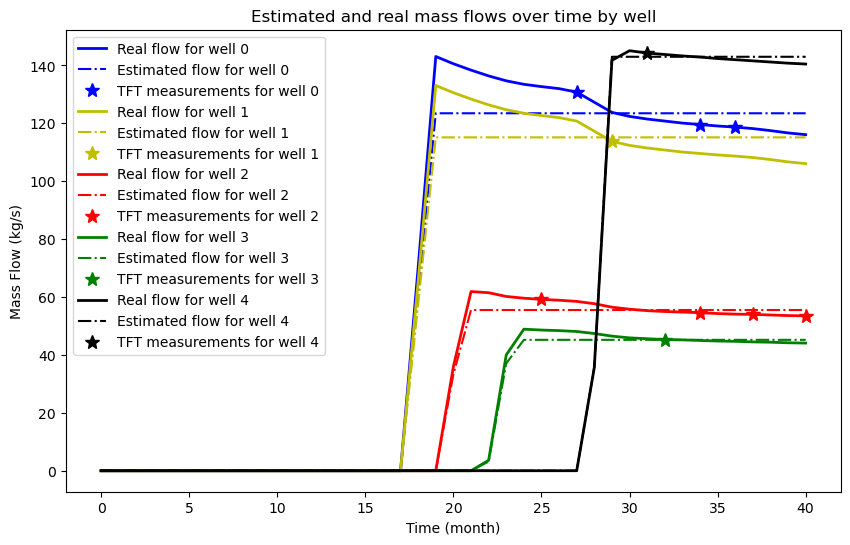

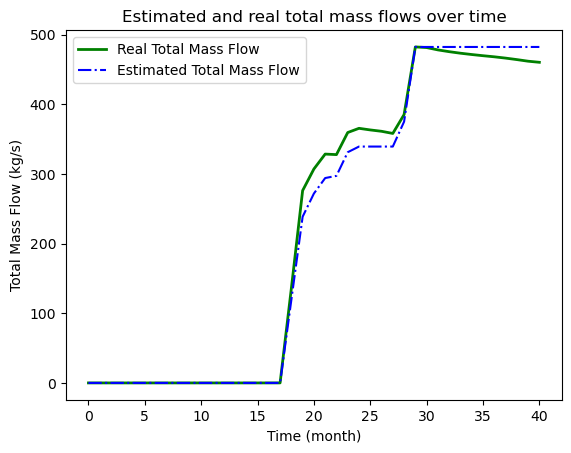

In [3]:
pTrain = 10
pTest = 20
#rand.seed(1)
SolveRMSE(filename, pTrain, pTest, ridgeCoef=0, k=0, suppress=False)

In [ ]:
kk = 4
numRuns = 20
RMSEs = zeros(kk,numRuns)
# Use same random seeds for each k.
seeds = np.random.randint(10**10, size=numRuns)
for k in range(kk):
    for run in range(numRuns):
        rand.seed(seeds[run])
        RMSEs[k,run] = SolveRMSE(filename, pTrain, pTest, ridgeCoef=0, k=k, suppress=True)
    
RMSEs

/tmp/ipykernel_1971/238034231.py:8: DeprecationWarning: Seeding based on hashing is deprecated
since Python 3.9 and will be removed in a subsequent version. The only 
supported seed types are: None, int, float, str, bytes, and bytearray.
  rand.seed(seeds[run])
/tmp/ipykernel_1971/238034231.py:8: DeprecationWarning: Seeding based on hashing is deprecated
since Python 3.9 and will be removed in a subsequent version. The only 
supported seed types are: None, int, float, str, bytes, and bytearray.
  rand.seed(seeds[run])
/tmp/ipykernel_1971/238034231.py:8: DeprecationWarning: Seeding based on hashing is deprecated
since Python 3.9 and will be removed in a subsequent version. The only 
supported seed types are: None, int, float, str, bytes, and bytearray.
  rand.seed(seeds[run])
/tmp/ipykernel_1971/238034231.py:8: DeprecationWarning: Seeding based on hashing is deprecated
since Python 3.9 and will be removed in a subsequent version. The only 
supported seed types are: None, int, float, str

In [ ]:
# Calculate Standard Deviations
stds = np.zeros(kk)
for k in range(kk):
    stds[k] = np.std(np.array(RMSEs[k,:]).astype(float))
# Calculate means
means = np.array([np.mean(RMSEs[i,:]) for i in range(kk)]).astype(float)
# Calculate 95% CIs
uppers = [means[k] + 1.96*stds[k]/np.sqrt(numRuns) for k in range(kk)]
lowers = [means[k] - 1.96*stds[k]/np.sqrt(numRuns) for k in range(kk)]
means, stds, lowers, uppers

In [ ]:
for run in range(numRuns):
    if run==0:
        plt.plot(range(kk), RMSEs[:,run], "b-.", alpha=0.5, label="RMSE of Individual runs with set seed")
    else:
        plt.plot(range(kk), RMSEs[:,run], "b-.", alpha=0.5)
plt.plot(range(kk), means, "g-", lw=3, label="Mean RMSE")
plt.fill_between(range(kk), lowers, uppers, color="g", alpha=0.3, label="95% Confidence Interval for RMSE")
plt.yscale("linear")
plt.title("Plot of mean RMSE against polynomial degree (without regularisation)")
plt.xlabel("Highest degree k")
plt.ylabel("RMSE [kg/s]   (shown in log scale)")
plt.legend()


In [105]:
k

In [108]:
seeds[run]

8369359157

In [107]:
run